In [93]:
!pip install pandas numpy matplotlib seaborn nltk scikit-learn
!pip install bertopic
!pip install sentence-transformers
!pip install wordcloud
!pip install gensim
!pip install pycountry
!pip install pyLDAvis

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pycountry
import nltk
import re
import string
import gensim.corpora as corpora
from gensim import corpora
from gensim.models.coherencemodel import CoherenceModel
from collections import Counter
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from wordcloud import WordCloud
from nltk.corpus import stopwords
from sklearn.metrics.pairwise import cosine_similarity
from __future__ import print_function
import pyLDAvis
import pyLDAvis.lda_model
pyLDAvis.enable_notebook()
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from gensim.models import LdaModel


In [95]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [96]:
# Load the dataset from CSV using a custom line terminator to handle formatting issues
df = pd.read_csv('/content/omicron_tweets.csv', lineterminator='\n')
print("Dataset loaded successfully using lineterminator='\\n'.")

Dataset loaded successfully using lineterminator='\n'.


In [97]:
df.keys()

Index(['tweet_id', 'date', 'text', 'user_name', 'user_location',
       'user_description', 'user_created', 'user_followers', 'user_friends',
       'user_favourites', 'hashtags', 'source', 'is_retweet\r'],
      dtype='object')

In [98]:
df.head()

,tweet_id,date,text,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,hashtags,source,is_retweet\r
0,1.46516E+18,2021-11-29 03:36:59+00:00,Will Boris Johnson ever learn his lesson after...,James robertson,NaN,NaN,2013-04-22 19:41:30+00:00,303.0,188,84059,NaN,Twitter for Android,FALSE\r
1,1.46516E+18,2021-11-29 03:36:57+00:00,#Omicron so hot; it’s being rush shipped in De...,Gene Bulmer,East Coast,"#ChristFollower, #Leader, Husband, Father, #Ru...",2014-11-10 22:43:27+00:00,99.0,162,745,['Omicron'],Twitter for iPhone,FALSE\r
2,1.46516E+18,2021-11-29 03:36:56+00:00,@JoeBiden How To Stop The Spread of Coronaviru...,Andrew Arcie Galendez (ᚪᚾᛞᚱᛖᚹ᛫),NaN,I AM PURE FILIPINO; BOTH MY PARENTS ARE FILIPI...,2021-01-28 11:31:59+00:00,114.0,3223,4830,NaN,Twitter for Android,FALSE\r
3,1.46516E+18,2021-11-29 03:36:56+00:00,Gold Coast leaders urge against overcautious r...,myGC.com.au,"Gold Coast, Australia","The Gold Coast's best news, local events, weat...",2009-03-30 03:54:34+00:00,12232.0,3191,271,['GoldCoastNews'],Zapier.com,FALSE\r
4,1.46516E+18,2021-11-29 03:36:55+00:00,What Is Omicron Radiation...\nhttps://t.co/QfK...,Ghost Of Gus Hall,Poughkeepsie Peoples Republic,Freelancer who knows a name and is lying to po...,2011-10-17 03:25:39+00:00,603.0,960,819,NaN,Twitter for Android,FALSE\r


In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8072 entries, 0 to 8071
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   tweet_id          8068 non-null   object 
 1   date              8066 non-null   object 
 2   text              8066 non-null   object 
 3   user_name         8064 non-null   object 
 4   user_location     5988 non-null   object 
 5   user_description  7422 non-null   object 
 6   user_created      8063 non-null   object 
 7   user_followers    8063 non-null   float64
 8   user_friends      8063 non-null   object 
 9   user_favourites   8063 non-null   object 
 10  hashtags          4631 non-null   object 
 11  source            8061 non-null   object 
       8072 non-null   object 
dtypes: float64(1), object(12)
memory usage: 819.9+ KB


## Data Cleaning

In [100]:

df = df.drop_duplicates(subset='text').dropna(subset=['text'])

In [101]:
# Drop unnecessary columns that are not useful for topic modeling
columns_to_drop = ['tweet_id', 'user_description', 'user_created',
                   'user_friends', 'user_favourites', 'source', 'is_retweet\r']

df.drop(columns=columns_to_drop, inplace=True)

In [102]:
# Display the shape of the DataFrame (number of rows and columns) after dropping columns.
df.shape

(5301, 6)

In [103]:
# Convert the 'date' column to datetime format, handling any errors gracefully
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Filter tweets to keep only those from December 2021
df_december_2021 = df[(df['date'].dt.year == 2021) & (df['date'].dt.month == 12)].copy()

# Reset the index after filtering for cleaner access and visualization
df_december_2021.reset_index(drop=True, inplace=True)

# Print the number of tweets from December 2021 to confirm filtering worked
print(f"Number of tweets from December 2021: {len(df_december_2021)}")

Number of tweets from December 2021: 2636


In [104]:
# Set up preprocessing tools: English stopwords and a lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Define a function to clean tweet text
def clean_text(text):
    text = str(text).lower()  # lowercase
    text = re.sub(r'http\S+', '', text)  # remove URLs
    text = re.sub(r'@\w+|#\w+', '', text)  # remove mentions and hashtags
    text = re.sub(r'[^\x00-\x7F]+', '', text)  # remove emojis and non-ASCII
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove punctuation and numbers
    tokens = word_tokenize(text)  # tokenize

    # Remove stopwords and apply lemmatization
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

# Apply the cleaning function to each tweet and store in a new column 'clean_text'
df['clean_text'] = df['text'].apply(clean_text)

# Display original vs cleaned text for the first few rows
df[['text', 'clean_text']].head()


,text,clean_text
0,Will Boris Johnson ever learn his lesson after...,boris johnson ever learn lesson endless covid ...
1,#Omicron so hot; it’s being rush shipped in De...,hot rush shipped december variantofthemonth pa...
2,@JoeBiden How To Stop The Spread of Coronaviru...,stop spread coronavirus omicron variant delta ...
3,Gold Coast leaders urge against overcautious r...,gold coast leader urge overcautious response o...
4,What Is Omicron Radiation...\nhttps://t.co/QfK...,omicron radiation


In [105]:
# Filter out tweets with fewer than 4 meaningful words to reduce noise in modeling
df = df[df['clean_text'].str.split().str.len() > 3]

In [106]:
# Re-apply cleaning on 'text' column to ensure consistency (if needed later)
df['text'] = df['text'].apply(clean_text)

In [107]:
# Ensure user location values are stored as strings
df['user_location'] = df['user_location'].astype(str)

# Create a dictionary of country names and abbreviations using pycountry
countries = {country.name.lower(): country.name for country in pycountry.countries}
countries.update({country.alpha_2.lower(): country.name for country in pycountry.countries})
countries.update({country.alpha_3.lower(): country.name for country in pycountry.countries})

# Define a function to extract country names from user-provided location info
def extract_country(location):
    location = location.lower()
    for key in countries:
        if key in location:
            return countries[key]
    return None # Return None if no country match is found

# Apply the country extraction function to the 'user_location' column
df['country'] = df['user_location'].apply(extract_country)

In [108]:
# Display a sample of extracted country names for verification
# This helps to verify the country extraction process.
df[['user_location', 'country']].dropna().head(10)

,user_location,country
0,nan,Namibia
1,East Coast,American Samoa
2,nan,Namibia
3,"Gold Coast, Australia",Australia
5,nan,Namibia
6,"Calgary, Alberta",Albania
7,India,India
8,"Toronto, ON",Romania
9,bro city Manville dude,Brazil
10,Italia,Albania


## Exploratory Data Analysis - Hashtag Analysis & Visualization

In [109]:
# Count the occurrences of each unique value in the 'country' column and display the counts.
# This shows the distribution of tweets by extracted country.
df['country'].value_counts()

,count
country,
Namibia,1166
India,430
Canada,314
Albania,278
Argentina,219
...,...
Poland,1
Tunisia,1
El Salvador,1


In [110]:
# Overwrite the 'user_location' column with the extracted 'country' names.
# This standardizes the location information to country level.
df['user_location'] = df['country']

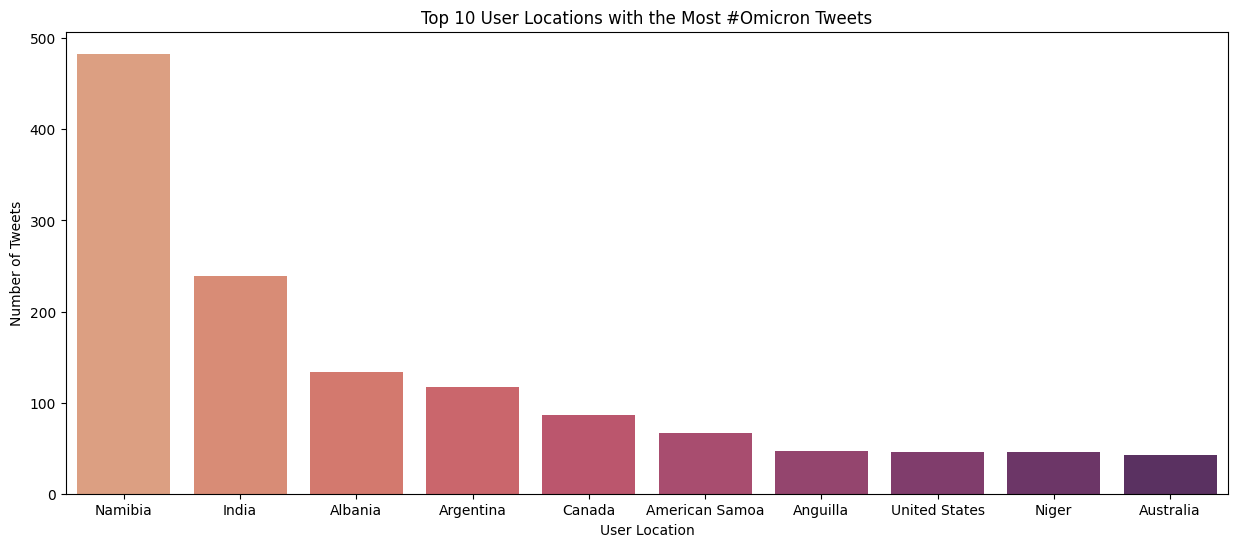

In [111]:
# count tweets with hashatg omicron and then plot a bar cjhart of it
# against the user_location to see which place had most number  of tweets with hashtag
# omicron use columns hashtags and user_location

# Filter the DataFrame to include only tweets with the hashtag 'omicron'
omicron_tweets = df[df['hashtags'].str.contains('omicron', na=False, case=False)]

# Count the occurrences of each user location for these tweets
location_counts = omicron_tweets['user_location'].value_counts().reset_index()
# Rename columns for clarity in the resulting DataFrame
location_counts.columns = ['user_location', 'tweet_count']

# Take the top N locations (e.g., top 10) for better visualization
top_n = 10
top_locations = location_counts.head(top_n)

# Plot a bar chart showing the top 10 countries by tweet count
plt.figure(figsize=(15, 6))
sns.barplot(x='user_location', y='tweet_count', data=top_locations, palette='flare')
plt.title(f'Top 10 User Locations with the Most #Omicron Tweets')
plt.xlabel('User Location')
plt.ylabel('Number of Tweets')
plt.show()

In [112]:
# Extract the list of cleaned documents ('clean_text' column) for use in BERTopic.
docs = df['clean_text'].tolist()

## BERTopic Execution

In [113]:
# Initialize the UMAP model for dimensionality reduction.

umap_model = UMAP(n_neighbors=10,        # Chosen to balance local structure preservation; smaller values emphasize fine-grained cluster shapes
                  n_components=2,        # Reduced to 2D for efficient visualization and clustering; standard for topic mapping
                  min_dist=0.0,          # Set to 0.0 to allow tight clustering and better separation between topics in low-dimensional space
                  metric='cosine',       # Cosine distance is more effective for high-dimensional embeddings like those from BERT
                  random_state=42        # Fixed seed to ensure reproducibility of UMAP layout and clustering results
                  )

In [114]:
# Initialize the HDBSCAN model for clustering.

hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=5,              # Set based on dataset size and goal to identify even smaller niche topics (tested values: 5, 10, 15)
                                metric='euclidean',              # Required for HDBSCAN input after UMAP transformation; UMAP output is in Euclidean space
                                cluster_selection_method='eom',  # 'Excess of Mass' method ensures selection of stable and significant clusters
                                prediction_data=True             # Enables later computation of topic probabilities for visualizations like topic distribution maps
                                )

In [115]:
# Initialize the SentenceTransformer model to generate embeddings for the text data.
# "all-MiniLM-L6-v2" is a pre-trained model that maps sentences to dense vectors.
# This model is used by BERTopic to create document embeddings.
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")  # or try "paraphrase-MiniLM-L3-v2"

In [ ]:
# Create and fit the BERTopic model to the documents.
# umap_model: The initialized UMAP model for dimensionality reduction.
# hdbscan_model: The initialized HDBSCAN model for clustering.
# language: The language of the documents.
# min_topic_size: The minimum number of documents in a topic.
# embedding_model: The initialized SentenceTransformer model for generating embeddings.
# calculate_probabilities: Set to True to calculate topic probabilities for each document.
# verbose: Set to True to display progress bars and other information during fitting.
topic_model = BERTopic(umap_model=umap_model,
                       hdbscan_model=hdbscan_model,
                       language="english",
                       min_topic_size=5,  # Lower value helps identify more granular and specific themes in short tweets
                       embedding_model=embedding_model,
                       calculate_probabilities=True, # Enables soft assignment of documents to topics and supports probability-based visualizations
                       verbose=True # Displays model training logs, useful for debugging and understanding processing flow
                       )

# Apply BERTopic to the cleaned tweet corpus; returns topic assignments and per-document probabilities
topics, probs = topic_model.fit_transform(docs)

2025-07-22 13:52:49,116 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/148 [00:00<?, ?it/s]

2025-07-22 13:59:29,616 - BERTopic - Embedding - Completed ✓
2025-07-22 13:59:29,619 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


## Extracting Topics

In [ ]:
# Get information about the frequent topics, including topic ID, count, and representative words.
freq = topic_model.get_topic_info()
# Display the first 10 most frequent topics.
freq.head(10)

In [ ]:
# Get the top words and their scores for a specific topic (in this case, topic 0, which is often the largest).
# This helps in understanding the content of the topic.
topic_model.get_topic(0)  # Select the most frequent topic

In [ ]:
# Access the predicted topic assignments for the first 10 documents.
# -1 typically represents outlier documents that were not assigned to any topic.
topic_model.topics_[:10]

In [120]:
# Visualize the topics in a 2D scatter plot based on their UMAP embeddings.
# This helps in understanding the relationships and distances between topics.
topic_model.visualize_topics()

In [121]:
# Visualize the topic distribution for a specific document (in this case, document at index 100).
# The bar chart shows the probability of the document belonging to each topic.
# min_probability: Filter topics with probability below this threshold.
topic_model.visualize_distribution(probs[100], min_probability=0.015)

In [122]:
# Visualize the hierarchical structure of the topics as a dendrogram.
# This helps in understanding how topics are related and can be merged.
# top_n_topics: Display the hierarchy for the top N most frequent topics.
topic_model.visualize_hierarchy(top_n_topics=50)

In [123]:
# Visualize the top words for each topic as a bar chart.
# This provides a quick overview of the key terms for the most frequent topics.
# top_n_topics: Display the bar charts for the top N most frequent topics.
topic_model.visualize_barchart(top_n_topics=5)

In [124]:
# Visualize the similarity between topics as a heatmap.
# This helps in identifying topics that are semantically close to each other.
# n_clusters: Number of clusters to group topics by in the heatmap.
# width, height: Dimensions of the heatmap.
topic_model.visualize_heatmap(n_clusters=2, width=1000, height=1000)

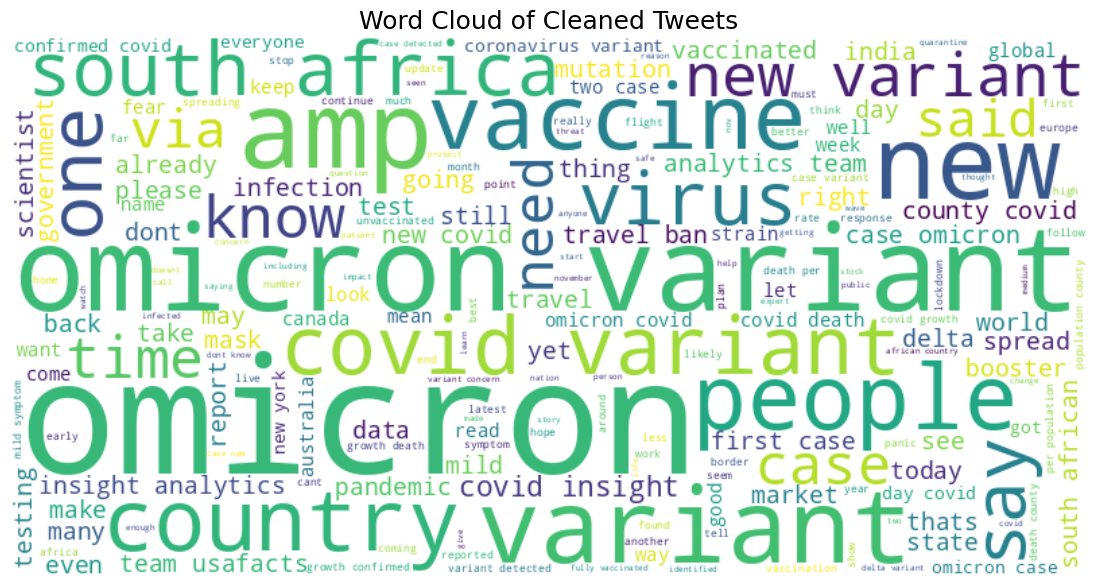

In [125]:
# Combine all the cleaned text data into a single string for the word cloud.
all_words = ' '.join(df['text'].astype(str))

# Generate a word cloud from the combined text.
# width, height: Dimensions of the word cloud image.
# background_color: The background color of the word cloud.
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

# Display the generated word cloud.
plt.figure(figsize=(15, 7)) # Set the figure size.
plt.imshow(wordcloud, interpolation='bilinear') # Display the word cloud image.
plt.axis('off') # Turn off the axis.
plt.title("Word Cloud of Cleaned Tweets", fontsize=18) # Set the title.
plt.show() # Show the plot.

In [126]:
# Visualize the term rank of words across all topics.
# This shows how important each word is for distinguishing topics.
topic_model.visualize_term_rank()

## Topic Updates and Reduction

In [127]:
# Update the topics by re-calculating the topic representations using a new n-gram range.
# docs: The documents used for updating.
# n_gram_range: The range of n-grams to consider (e.g., (1, 2) includes unigrams and bigrams).
# top_n_words: The number of top words to represent each topic.
topic_model.update_topics(docs, n_gram_range=(1, 2), top_n_words=10)

In [128]:
# Get the top words and their scores for a specific topic (topic 0) after the topic update.
# This shows how the topic representation changed with the new n-gram range.
topic_model.get_topic(0)   # We select topic that we viewed before

[('vaccine', 0.023779396538926696),
 ('vaccinated', 0.00947661481488555),
 ('vaccination', 0.0091966118279125),
 ('gen', 0.00646460803682254),
 ('jab', 0.00632701028768328),
 ('booster', 0.006297269662763091),
 ('vaccination rate', 0.006180259295028893),
 ('nation', 0.006107457413637509),
 ('unvaccinated', 0.006091272052940709),
 ('yall', 0.005940666942966943)]

In [129]:
# Reduce the number of topics to a specified number (e.g., 5).
# This can be useful for simplifying the topic structure.
# docs: The documents used for reduction.
# nr_topics: The desired number of topics after reduction.
topic_model.reduce_topics(docs, nr_topics=5)

2025-07-22 13:51:27,842 - BERTopic - Topic reduction - Reducing number of topics
2025-07-22 13:51:27,872 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-07-22 13:51:28,245 - BERTopic - Representation - Completed ✓
2025-07-22 13:51:28,250 - BERTopic - Topic reduction - Reduced number of topics from 209 to 5


In [130]:
# Access and print the newly updated topic assignments for each document after reduction.
# The values represent the new topic ID assigned to each document.
print(topic_model.topics_)

[0, 0, 0, -1, 0, 0, 0, 0, 0, -1, -1, 0, -1, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, -1, -1, 0, 0, -1, -1, 0, -1, 0, 0, -1, 0, 0, -1, -1, -1, -1, 0, 0, 0, 0, -1, 0, -1, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 3, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, -1, -1, 0, -1, 0, 0, -1, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, -1, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, -1, -1, 0, 0, 0, 0, 0, -1, -1, 0, -1, 0, -1, -1, -1, -1, 0, 0, 0, 0, -1, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, -1, 0, -1, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, -1, 0, 3, 0, -1, 0, 0, -1, 0, -1, 0, 0, -1, 0, 0, -1, 0, -1, 0, 0, 0, 0, -1, -1, 0, 0, -1, -1, -1, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, -1, -1, -1, -1, 0, -1, 0, 0, 0, 0, -1, 0, 0, -1, 0, 0, 0, 0, 0, 0, -1, -1, -1, 0, -1, 0, 0, -1, 0, 0, 0, 0, -1, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, -1, 0, -1, 0, -1, 0, 0, 0, 0, 0, 0, -1

In [131]:
# Find topics that are most similar to a given search term ("Australia").
# top_n: The number of most similar topics to retrieve.
# similar_topics: A list of topic IDs similar to the search term.
# similarity: A list of similarity scores corresponding to the similar topics.
similar_topics, similarity = topic_model.find_topics("Australia", top_n=10); similar_topics

[1, 0, -1, 2, 3]

In [132]:
# Get the top words and their scores for a specific topic (topic 3 in this case).
# This helps in understanding the content of this particular topic after reduction.
topic_model.get_topic(3)

[('guest list', 0.47406224145141707),
 ('guest', 0.4448817094220114),
 ('list due', 0.4037318666456502),
 ('actor cut', 0.4037318666456502),
 ('cut guest', 0.4037318666456502),
 ('actor', 0.39505186787618085),
 ('list', 0.3881648379870165),
 ('wedding', 0.38771333935612345),
 ('cut', 0.36619815757486623),
 ('booked actor', 0.33148461586699357)]

## Coherence Score for BERTopic

In [133]:
# Extract documents (original cleaned dataset)
# This extracts the 'text' column (which was cleaned earlier) and converts it to a list.
docs = df['text'].dropna().astype(str).tolist()

# Preprocess using BERTopic's internal preprocessor
# Use the same preprocessing steps as BERTopic for consistency.
cleaned_docs = topic_model._preprocess_text(docs)

# xtract the vectorizer from the topic model
# Access the CountVectorizer used internally by BERTopic.
vectorizer = topic_model.vectorizer_model

# Use the vectorizer’s analyzer for consistent tokenization
# Get the analyzer function from the vectorizer to ensure consistent tokenization.
analyzer = vectorizer.build_analyzer()
tokens = [analyzer(doc) for doc in cleaned_docs]

# Create a Gensim dictionary and corpus
# Create a dictionary mapping words to unique IDs.
dictionary = corpora.Dictionary(tokens)
# Create a corpus in bag-of-words format (list of (token_id, count) tuples).
corpus = [dictionary.doc2bow(token_list) for token_list in tokens]

# Get topic words from the model, excluding -1 (outliers)
# Retrieve the topics and their word distributions from the BERTopic model.
topics = topic_model.get_topics()
# Remove the outlier topic (-1) as it doesn't represent a coherent topic.
topics.pop(-1, None)

# Convert topics to a list of top words
# Extract the top words for each remaining topic.
topic_words = [
    [word for word, _ in topic_model.get_topic(topic) if word != ""]
    for topic in topics
]

# Calculate Coherence Score
# Initialize the CoherenceModel using the C_V measure.
coherence_model = CoherenceModel(
    topics=topic_words,     # A list of top words per topic generated by the topic model (e.g., BERTopic)
    texts=tokens,           # Preprocessed version of the documents as lists of tokens; required for reference word context
    corpus=corpus,          # Bag-of-Words representation of the dataset; supports statistical term co-occurrence analysis
    dictionary=dictionary,  # Gensim dictionary mapping word IDs to terms; used for matching tokens to model topics
    coherence='c_v'         # Chosen coherence metric 'c_v' is widely used and suitable for short texts; it combines a sliding window, word co-occurrence, and indirect confirmation measure using normalized pointwise mutual information (NPMI)
)
# Calculate the coherence score.
coherence_score = coherence_model.get_coherence()

# Print the calculated coherence score.
print(f"Coherence Score (c_v) for Bert: {coherence_score:.4f}")

Coherence Score (c_v) for Bert: 0.8643


In [134]:
# Get the coherence score for each individual topic.
coherence_per_topic = coherence_model.get_coherence_per_topic()
# Display the coherence scores for the first 5 topics.
coherence_per_topic[:5]

[0.4859923108707281,
 0.9988951983183527,
 0.9744282188775767,
 0.9978071061863268]

## TF-IDF

In [135]:
# Get topic sizes and sort them in descending order.
topic_info = topic_model.get_topic_info()
# Exclude the outlier topic (-1) and get the top 5 topic IDs.
top_topics = topic_info[topic_info.Topic != -1].head(5)['Topic'].tolist()

# Print the top words for each of the top 5 topics based on their c-TF-IDF scores.
print("\n--- Top Words by c-TF-IDF Scores for Top 5 Topics ---")
for topic_id in top_topics:
    print(f"\n=== Topic {topic_id} ===")
    # Get the topic representation (words and scores) for the current topic ID.
    terms = topic_model.topic_representations_[topic_id]
    # Print the top 10 keywords and their scores for the topic.
    for word, score in terms[:10]:
        print(f"{word}: {score:.3f}")


--- Top Words by c-TF-IDF Scores for Top 5 Topics ---

=== Topic 0 ===
variant: 0.040
omicron: 0.039
covid: 0.027
new: 0.022
case: 0.022
omicron variant: 0.017
amp: 0.013
south: 0.013
country: 0.012
vaccine: 0.012

=== Topic 1 ===
loan: 0.373
within: 0.322
loan repaid: 0.203
condition billion: 0.203
bankruptcy: 0.203
bankruptcy get: 0.203
billion loan: 0.203
year interest: 0.203
case bankruptcy: 0.203
get money: 0.203

=== Topic 2 ===
postpone travel: 0.374
postpone: 0.358
travel due: 0.310
older postpone: 0.310
people older: 0.310
advises people: 0.300
advises: 0.281
older: 0.276
travel: 0.252
due: 0.208

=== Topic 3 ===
guest list: 0.474
guest: 0.445
list due: 0.404
actor cut: 0.404
cut guest: 0.404
actor: 0.395
list: 0.388
wedding: 0.388
cut: 0.366
booked actor: 0.331


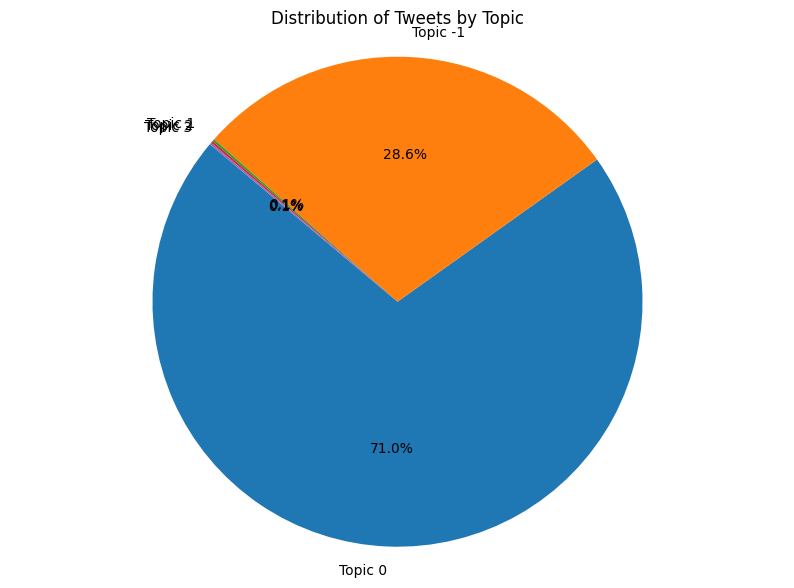

In [136]:
# Get the sizes of each topic.
topic_sizes = topic_model.topic_sizes_
# Convert the topic sizes to a pandas DataFrame for easier manipulation.
topic_sizes_df = pd.DataFrame(topic_sizes.items(), columns=['Topic', 'Size'])
# Sort the DataFrame by topic size in descending order.
topic_sizes_df = topic_sizes_df.sort_values(by='Size', ascending=False)

# Create a pie chart to visualize the distribution of tweets across topics.
plt.figure(figsize=(10, 7)) # Set the figure size.
# Plot the pie chart using topic sizes and labels.
plt.pie(topic_sizes_df['Size'], labels=[f"Topic {t}" for t in topic_sizes_df['Topic']],
        autopct='%1.1f%%', startangle=140) # autopct displays percentage, startangle rotates the chart.
plt.title('Distribution of Tweets by Topic') # Set the title.
plt.axis('equal') # Ensure the pie chart is circular.
plt.show() # Display the plot.

In [137]:

print("\n\n--- Most Similar Topic Pairs ---")
# Get the embeddings for each topic.
embeddings = topic_model.topic_embeddings_
# Calculate the cosine similarity matrix between topic embeddings.
cos_sim = cosine_similarity(embeddings)

# Collect and sort similarity pairs
sim_pairs = []
# Iterate through the upper triangle of the similarity matrix to get unique pairs.
for i in range(len(cos_sim)):
    for j in range(i+1, len(cos_sim)):
        # Append the topic indices and their similarity score as a tuple.
        sim_pairs.append((i, j, cos_sim[i][j]))

# Sort the similarity pairs in descending order based on the similarity score.
sim_pairs = sorted(sim_pairs, key=lambda x: x[2], reverse=True)[:5]

# Retrieve updated topic info after reduction to get topic names.
updated_topic_info = topic_model.get_topic_info()

# Print the most similar topic pairs with their names and similarity scores.
for i, j, sim in sim_pairs:
    # Get the topic names for the current pair of topic indices.
    label_i = updated_topic_info[updated_topic_info["Topic"] == i]["Name"].values[0]
    label_j = updated_topic_info[updated_topic_info["Topic"] == j]["Name"].values[0]
    # Print the topic names and their similarity score, formatted to 3 decimal places.
    print(f" ({label_i}) <-->  ({label_j}): {sim:.3f}")



--- Most Similar Topic Pairs ---
 (0_variant_omicron_covid_new) <-->  (1_loan_within_loan repaid_condition billion): 0.995
 (1_loan_within_loan repaid_condition billion) <-->  (3_guest list_guest_list due_actor cut): 0.310
 (0_variant_omicron_covid_new) <-->  (3_guest list_guest_list due_actor cut): 0.294
 (1_loan_within_loan repaid_condition billion) <-->  (2_postpone travel_postpone_travel due_older postpone): 0.235
 (0_variant_omicron_covid_new) <-->  (2_postpone travel_postpone_travel due_older postpone): 0.232


## LDA

In [138]:
# Tokenize the cleaned tweets by splitting them into lists of words.
tokenized_docs = [doc.split() for doc in df['clean_text']]

# Create a Gensim Dictionary from the tokenized documents.
# This maps each unique word to an integer ID.
dictionary = corpora.Dictionary(tokenized_docs)
# Create a Gensim Corpus in bag-of-words format.
# Each document is represented as a list of (token_id, count) tuples.
corpus = [dictionary.doc2bow(text) for text in tokenized_docs]

# Train the LDA model.
# corpus: The bag-of-words corpus.
# id2word: The dictionary mapping IDs to words.
# num_topics: The desired number of topics. Matching BERTopic's reduced number (5) for comparison.
# passes: The number of passes through the corpus during training.
# random_state: For reproducibility.
lda_model = LdaModel(
                  corpus=corpus,              # Bag-of-Words representation of the preprocessed tweet corpus; required for LDA's term distribution learning
                  id2word=dictionary,         # Dictionary mapping word IDs to actual words; helps the model interpret word co-occurrence context
                  num_topics=5,               # Selected to align with BERTopic and K-Means configurations for fair comparison; provides a manageable number of interpretable themes
                  passes=10,                  # Number of passes through the entire corpus during training; set to 10 to ensure convergence and improve topic quality
                  random_state=42             # Fixed seed for reproducibility, ensuring consistent topic output across runs
              )
# View the topics generated by the LDA model.
# Each topic is represented by its top words and their weights.
topics = lda_model.print_topics()
for topic in topics:
    print(topic)

(0, '0.052*"covid" + 0.028*"death" + 0.022*"county" + 0.022*"team" + 0.021*"growth" + 0.020*"insight" + 0.020*"analytics" + 0.020*"usafacts" + 0.019*"confirmed" + 0.015*"amp"')
(1, '0.023*"variant" + 0.022*"case" + 0.014*"omicron" + 0.012*"amp" + 0.011*"two" + 0.011*"covid" + 0.011*"first" + 0.011*"south" + 0.010*"india" + 0.008*"positive"')
(2, '0.053*"variant" + 0.038*"omicron" + 0.034*"new" + 0.031*"case" + 0.016*"covid" + 0.013*"country" + 0.012*"travel" + 0.010*"africa" + 0.010*"detected" + 0.009*"world"')
(3, '0.012*"amp" + 0.012*"like" + 0.008*"world" + 0.006*"people" + 0.005*"market" + 0.005*"dont" + 0.005*"pandemic" + 0.005*"look" + 0.004*"mask" + 0.004*"come"')
(4, '0.024*"variant" + 0.021*"omicron" + 0.011*"new" + 0.011*"vaccine" + 0.011*"case" + 0.009*"people" + 0.007*"get" + 0.007*"vaccinated" + 0.007*"know" + 0.006*"infection"')


In [147]:
# Enable the pyLDAvis notebook extension for interactive visualization.
pyLDAvis.enable_notebook()
# Prepare the data for interactive visualization using pyLDAvis.
# lda_model: The trained LDA model.
# corpus: The bag-of-words corpus.
# dictionary: The Gensim dictionary.
vis = pyLDAvis.gensim.prepare(lda_model, corpus, dictionary)
# Display the interactive visualization.
pyLDAvis.display(vis)

In [146]:

# Get the top words for each topic from the trained LDA model.
# show_topic: Method to get the top words and their probabilities for a topic.
# topn: The number of top words to retrieve for each topic.
lda_topic_words = [
    [word for word, prob in lda_model.show_topic(i, topn=10)]
    for i in range(lda_model.num_topics)
]

# Calculate Coherence Score for the LDA model using the C_V measure.
# topics: The list of top words for each topic.
# texts: The tokenized documents used for training.
# corpus: The bag-of-words corpus.
# dictionary: The Gensim dictionary.
lda_coherence_model = CoherenceModel(
    topics=lda_topic_words,
    texts=tokenized_docs,  # Use the tokenized documents created earlier
    corpus=corpus,         # Use the corpus created earlier
    dictionary=dictionary,   # Use the dictionary created earlier
    coherence='c_v'
)

# Get the calculated coherence score for the LDA model.
lda_coherence_score = lda_coherence_model.get_coherence()

# Print the coherence score for the LDA model.
print(f"\n--- Coherence Score (c_v) for LDA: {lda_coherence_score:.4f} ---")


--- Coherence Score (c_v) for LDA: 0.5415 ---


## K-Means (BERT embeddings)

In [141]:


# Initialize TF-IDF Vectorizer.
# max_features: Limit the number of features (words) to the top 1000 most frequent.
vectorizer = TfidfVectorizer(max_features=1000)
# Fit the vectorizer to the cleaned text and transform the documents into TF-IDF vectors.
X = vectorizer.fit_transform(df['clean_text'])

# Initialize K-Means Clustering model.
# n_clusters: The desired number of clusters (topics).
# random_state: For reproducibility.
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10) # Added n_init for KMeans warning

# Fit the K-Means model to the TF-IDF vectors and predict the cluster labels for each document.
labels = kmeans.fit_predict(X)

# Add the cluster labels as a new column to the DataFrame.
df['kmeans_topic'] = labels

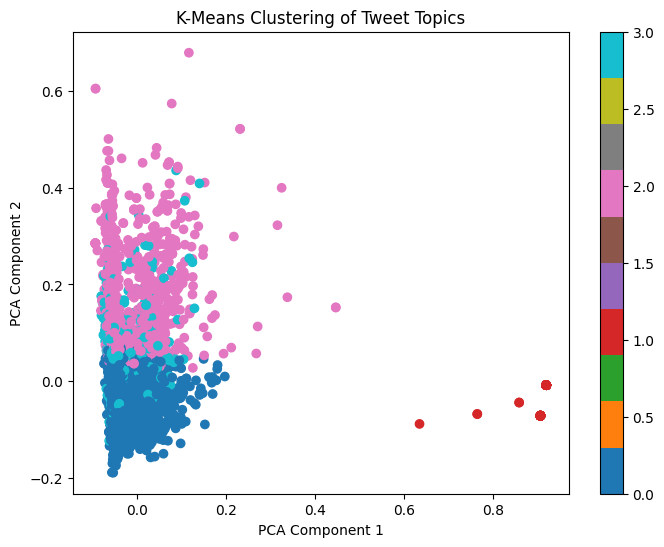

In [142]:

# Initialize PCA for dimensionality reduction to 2 components for visualization.
pca = PCA(n_components=2)
# Fit PCA to the TF-IDF vectors (converted to dense array) and transform them.
# or BERT embeddings - This comment indicates PCA can also be applied to BERT embeddings.
components = pca.fit_transform(X.toarray())

# Create a scatter plot to visualize the K-Means clusters in 2D PCA space.
plt.figure(figsize=(8,6)) # Set the figure size.
# Scatter plot: x and y coordinates from PCA components, color points by cluster label.
plt.scatter(components[:, 0], components[:, 1], c=labels, cmap='tab10') # cmap sets the color map.
plt.title("K-Means Clustering of Tweet Topics") # Set the title.
plt.xlabel("PCA Component 1") # Set x-axis label.
plt.ylabel("PCA Component 2") # Set y-axis label.
plt.colorbar() # Add a color bar to show the cluster mapping.
plt.show() # Display the plot.

In [143]:
# Count the number of documents assigned to each K-Means topic (cluster).
df['kmeans_topic'].value_counts()

,count
kmeans_topic,
0,3106
2,1066
3,409
1,131


Batches:   0%|          | 0/148 [00:00<?, ?it/s]

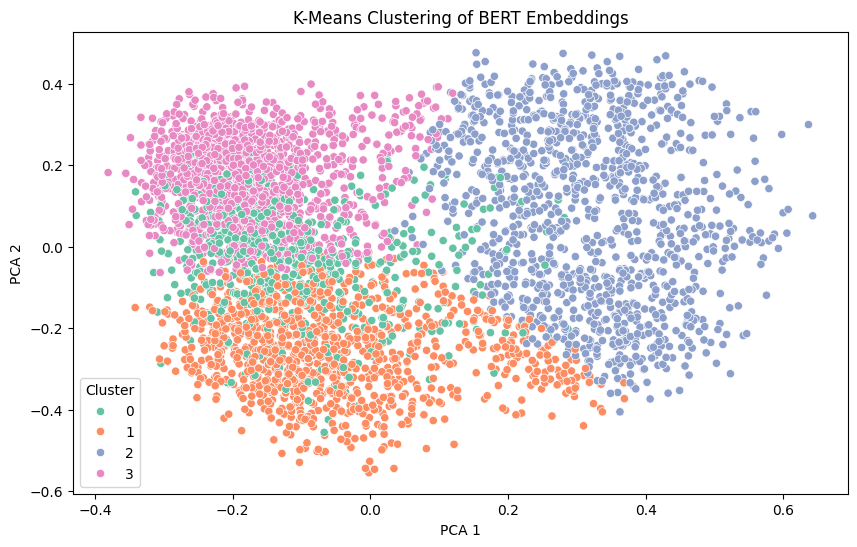

In [144]:
# Generate BERT embeddings for the cleaned text data.
# 'all-MiniLM-L6-v2' is the pre-trained model used to create the embeddings.
# show_progress_bar=True displays a progress bar during embedding generation.
model = SentenceTransformer('all-MiniLM-L6-v2')
bert_embeddings = model.encode(df['clean_text'].tolist(), show_progress_bar=True)

# Apply KMeans clustering to the BERT embeddings.
# n_clusters: The desired number of clusters.
# random_state: For reproducibility.
kmeans = KMeans(
    n_clusters=4,        # Number of clusters manually set to 4 to match the number of topics used in BERTopic and LDA for consistent comparison
    random_state=42,     # Fixed seed ensures reproducibility of clustering results across multiple runs
    n_init=10            # Number of initializations with different centroid seeds; set to 10 to ensure stability and avoid convergence to local minima (also suppresses future warnings in scikit-learn)
)

bert_kmeans_labels = kmeans.fit_predict(bert_embeddings)

# Add the BERT K-Means cluster labels as a new column to the DataFrame.
df['bert_kmeans_cluster'] = bert_kmeans_labels

# Visualize the BERT embeddings after reducing their dimensionality to 2 components using PCA.
pca = PCA(n_components=2)
bert_pca = pca.fit_transform(bert_embeddings)

# Create a scatter plot to visualize the K-Means clusters based on BERT embeddings in 2D PCA space.
plt.figure(figsize=(10, 6)) # Set the figure size.
# Use seaborn's scatterplot for plotting.
# x, y: Coordinates from the PCA components.
# hue: Color points based on their BERT K-Means cluster label.
# palette: Color palette for the clusters.
sns.scatterplot(x=bert_pca[:, 0], y=bert_pca[:, 1], hue=bert_kmeans_labels, palette='Set2')
plt.title("K-Means Clustering of BERT Embeddings") # Set the title.
plt.xlabel("PCA 1") # Set x-axis label.
plt.ylabel("PCA 2") # Set y-axis label.
plt.legend(title="Cluster") # Add a legend to show cluster colors.
plt.show() # Display the plot.

In [ ]:
import pandas as pd
from gensim.models.coherencemodel import CoherenceModel
from gensim import corpora
from sklearn.feature_extraction.text import TfidfVectorizer # Import TfidfVectorizer


# Get documents for K-Means (cleaned text).
kmeans_docs = df['clean_text'].tolist()

# Get cluster labels from K-Means model.
# Assuming 'kmeans' model is already trained on TF-IDF in cell AEBJdbnVIrpW
kmeans_labels = kmeans.labels_

# Find the top words for each K-Means cluster.
# This requires an approach to extract representative words for flat clusters.
# One common way is to look at the terms with the highest TF-IDF score within each cluster.

# Re-initialize and fit the TF-IDF vectorizer to get the vocabulary and inverse document frequency.
# This should use the same parameters as the vectorizer used for KMeans clustering (cell AEBJdbnVIrpW).
vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(df['clean_text'])

# Get the feature names (words) from the vectorizer *after* max_features has been applied.
feature_names = vectorizer.get_feature_names_out()
# Create a DataFrame of TF-IDF vectors with the correct feature names.
tfidf_df = pd.DataFrame(X.toarray(), columns=feature_names)
# Add the K-Means cluster labels to the TF-IDF DataFrame.
tfidf_df['cluster'] = kmeans_labels

kmeans_topic_words = []
n_top_words = 10 # number of top words to consider for coherence calculation

# Iterate through each unique cluster ID.
for cluster_id in sorted(tfidf_df['cluster'].unique()):
    # Select the TF-IDF vectors belonging to the current cluster and drop the 'cluster' column.
    cluster_tfidf_df = tfidf_df[tfidf_df['cluster'] == cluster_id].drop(columns=['cluster'])

    # Sum the TF-IDF scores for each word across all documents in the cluster.
    sum_tfidf = cluster_tfidf_df.sum(axis=0)

    # Get the top words for this cluster based on their summed TF-IDF scores.
    # nlargest(n_top_words) returns the top N words based on their sum_tfidf values.
    top_words_indices = sum_tfidf.nlargest(n_top_words).index
    # Convert the indices (which are the feature names/words) to a list.
    top_words = top_words_indices.tolist()
    # Append the list of top words for the current cluster to the main list.
    kmeans_topic_words.append(top_words)

# Create Gensim Dictionary and Corpus for K-Means documents for coherence calculation.
# Use the same tokenization/preprocessing as used for TF-IDF.
# Assuming 'clean_text' is already tokenized by space, adjust if necessary.
kmeans_tokens = [doc.split() for doc in kmeans_docs]

# Create a dictionary mapping words to unique IDs from the K-Means tokens.
kmeans_dictionary = corpora.Dictionary(kmeans_tokens)
# Create a corpus in bag-of-words format from the K-Means tokens and dictionary.
kmeans_corpus = [kmeans_dictionary.doc2bow(tokens) for tokens in kmeans_tokens]

# Calculate Coherence Score for K-Means using the C_V measure.
# topics: The list of top words for each K-Means cluster.
# texts: The tokenized documents.
# corpus: The bag-of-words corpus for K-Means.
# dictionary: The dictionary for K-Means.
kmeans_coherence_model = CoherenceModel(
    topics=kmeans_topic_words,
    texts=kmeans_tokens,     # Use the tokenized documents
    corpus=kmeans_corpus,    # Use the corpus
    dictionary=kmeans_dictionary, # Use the dictionary
    coherence='c_v'
)

# Get the calculated coherence score for the K-Means model.
kmeans_coherence_score = kmeans_coherence_model.get_coherence()

# Print the coherence score for the K-Means model.
print(f"\n--- Coherence Score (c_v) for K-Means: {kmeans_coherence_score:.4f} ---")

# Optional: Get coherence per topic for K-Means and print them.
kmeans_coherence_per_topic = kmeans_coherence_model.get_coherence_per_topic()
print("\nCoherence per topic for K-Means:")
for i, coherence in enumerate(kmeans_coherence_per_topic):
    print(f"Topic {i}: {coherence:.4f}")